## Prepare Dataset

In [74]:
import pandas as pd
df = pd.read_csv("Weather_Integrated_Dataset.csv")
# 1. Ensure the 'Datetime' column is formatted as actual pandas datetime objects
df['Datetime'] = pd.to_datetime(df['Datetime'])

# 2. Filter the dataframe to keep only rows >= your target start time
start_time = '2026-06-22 12:48:00'
df = df[df['Datetime'] >= start_time]

# 3. Reset the index so your row numbers start cleanly at 0 again
df = df.reset_index(drop=True)

# Verify the result
df.head()


,Datetime,Hour,DayName,Weekend,DayOfWeek,IndoorTemp,IndoorHumidity,OutdoorTemp,OutdoorHumidity,Rain,CloudCover,WindSpeed
0,2026-06-22 12:48:05,12,Monday,0,0,24.8,65.0,26.380000,91.34115,0.0,98.200000,3.898234
1,2026-06-22 12:49:05,12,Monday,0,0,24.8,64.5,26.369167,91.42090,0.0,98.183334,3.873381
2,2026-06-22 12:50:05,12,Monday,0,0,24.9,63.9,26.358334,91.50064,0.0,98.166664,3.848528
3,2026-06-22 12:51:05,12,Monday,0,0,24.9,63.4,26.347500,91.58039,0.0,98.150000,3.823675
4,2026-06-22 12:52:05,12,Monday,0,0,24.9,62.8,26.336666,91.66014,0.0,98.133330,3.798822


In [75]:
import pandas as pd

# 1. Ensure Datetime is a proper datetime object and set it as the index
df['Datetime'] = pd.to_datetime(df['Datetime'])
df = df.set_index('Datetime')

# 2. Isolate only the continuous numerical columns that make sense to average
numerical_cols = [
    'IndoorTemp', 'IndoorHumidity',
    'OutdoorTemp', 'OutdoorHumidity',
    'Rain', 'CloudCover', 'WindSpeed'
]

# 3. Downsample to 5-minute chunks ('5min') and calculate the mean
df_5min = df[numerical_cols].resample('5min').mean()

# Drop any blank rows (in case there were missing chunks in your original data)
df_5min = df_5min.dropna()

# 4. Rebuild the time and calendar features based on the new 5-minute timestamps
df_5min['Hour'] = df_5min.index.hour
df_5min['DayOfWeek'] = df_5min.index.dayofweek # Monday=0, Sunday=6
df_5min['DayName'] = df_5min.index.day_name()
df_5min['Weekend'] = df_5min['DayOfWeek'].apply(lambda x: 1 if x >= 5 else 0)

# 5. Reset the index so 'Datetime' becomes a normal column again
df_5min = df_5min.reset_index()

# Check the results
df_5min.head()

,Datetime,IndoorTemp,IndoorHumidity,OutdoorTemp,OutdoorHumidity,Rain,CloudCover,WindSpeed,Hour,DayOfWeek,DayName,Weekend
0,2026-06-22 12:45:00,24.80,64.75,26.374583,91.381025,0.0,98.191667,3.885807,12,0,Monday,0
1,2026-06-22 12:50:00,24.86,63.02,26.336666,91.660136,0.0,98.133333,3.798822,12,0,Monday,0
2,2026-06-22 12:55:00,24.70,61.68,26.282500,92.058876,0.0,98.050000,3.674558,12,0,Monday,0
3,2026-06-22 13:00:00,24.62,62.90,26.238333,92.362474,0.0,97.766666,3.607138,13,0,Monday,0
4,2026-06-22 13:05:00,24.66,62.20,26.209167,92.523360,0.0,97.183333,3.624982,13,0,Monday,0


In [76]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans

# Calculate rate of change for temperature and humidity
df_5min['dT'] = df_5min['IndoorTemp'].diff().fillna(0)
df_5min['dH'] = df_5min['IndoorHumidity'].diff().fillna(0)

# Calculate the Thermal Gradient
df_5min['Gradient'] = df_5min['OutdoorTemp'] - df_5min['IndoorTemp']

# ==========================================
# 2. SCHEDULE MASKING & K-MEANS CLUSTERING
# ==========================================
# Default everything to OFF (0) initially
df_5min['AC_State'] = 0

# Define active business hours for the initial ML guess
active_days = df_5min['DayOfWeek'].isin([0, 2, 4])
active_hours = (df_5min['Hour'] >= 9) & (df_5min['Hour'] < 18)
uncertain_mask = active_days & active_hours

# Run K-Means only on the uncertain times
uncertain_data = df_5min[uncertain_mask].copy()
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
features = ['dT', 'dH', 'Gradient']
uncertain_data['cluster'] = kmeans.fit_predict(uncertain_data[features])

# Identify the AC ON cluster (steepest temperature drop)
on_cluster_index = np.argmin(kmeans.cluster_centers_[:, 0])
uncertain_data['Predicted_AC'] = (uncertain_data['cluster'] == on_cluster_index).astype(int)

# Map ML predictions back to the main dataframe
df_5min.loc[uncertain_mask, 'AC_State'] = uncertain_data['Predicted_AC']

# ==========================================
# 3. THE FIX: ROBUST PHYSICS OVERRIDES
# ==========================================
# Override A: The Thermodynamic Limit (Accounts for DHT22 and API Error)
# 1. Widen the margin to 2.5°C to survive sensor inaccuracies.
is_colder_than_outside = df_5min['IndoorTemp'] < (df_5min['OutdoorTemp'] - 2.5)
# 2. Prevent morning thermal lag from causing false positives.
is_not_warming = df_5min['dT'] <= 0.05
temp_override = is_colder_than_outside & is_not_warming

# Override B: Rapid Mechanical Cooling Threshold
# A drop faster than -0.15°C in 5 minutes is mathematically impossible without an AC.
cooling_override = df_5min['dT'] < -0.15

# Apply the overrides: Force AC_State to 1 regardless of the schedule or ML
df_5min.loc[temp_override | cooling_override, 'AC_State'] = 1

# Override C: The Thermodynamic Kill Switch (Negative Override)
# If the temperature is actively rising by more than 0.05°C per 5 mins,
# the AC is definitively OFF, regardless of what K-Means predicted.
warming_override = df_5min['dT'] > 0.05
df_5min.loc[warming_override, 'AC_State'] = 0

# ==========================================
# 4. MECHANICAL SMOOTHING & CLEANUP
# ==========================================
# Apply a 15-minute rolling median (window=3) to fix flickering/sensor noise
df_5min['AC_State'] = df_5min['AC_State'].rolling(window=7, center=True).median()
df_5min['AC_State'] = df_5min['AC_State'].fillna(0).astype(int)

# Drop calculation columns we no longer need to keep the final dataframe clean
df_final = df_5min.drop(columns=['Hour', 'DayOfWeek', 'dT', 'dH', 'Gradient']).reset_index()

# Output the final results
print("Robust Labeling Complete! Final AC State breakdown (in 5-min intervals):")
print(df_final['AC_State'].value_counts())

Robust Labeling Complete! Final AC State breakdown (in 5-min intervals):
AC_State
0    1516
1     509
Name: count, dtype: int64


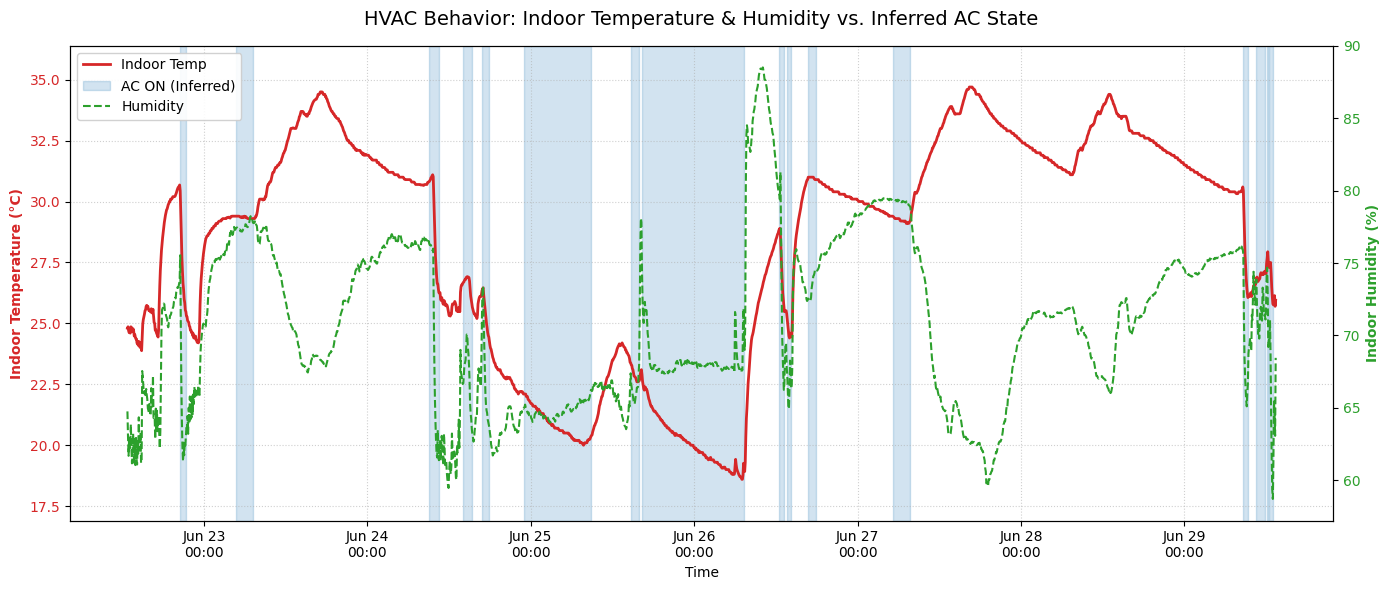

In [77]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Ensure Datetime is the index for plotting
if 'Datetime' in df_final.columns:
    df_plot = df_final.set_index('Datetime')
else:
    df_plot = df_final.copy()

# Filter a 2-day window to make the chart readable
# (Plotting 7 full days on one chart squashes the lines too much)
# Adjust these dates based on the actual dates in your dataset
start_date = '2026-06-22 00:00:00'
end_date = '2026-06-29 23:59:59'
df_subset = df_plot.loc[start_date:end_date]

# Create the plot figure
fig, ax1 = plt.subplots(figsize=(14, 6))

# 1. Plot the Indoor Temperature
color1 = 'tab:red'
ax1.set_xlabel('Time')
ax1.set_ylabel('Indoor Temperature (°C)', color=color1, fontweight='bold')
ax1.plot(df_subset.index, df_subset['IndoorTemp'], color=color1, linewidth=2, label='Indoor Temp')
ax1.tick_params(axis='y', labelcolor=color1)

# 2. Plot the Indoor Humidity on a secondary Y-axis
ax2 = ax1.twinx()
color2 = 'tab:green'
ax2.set_ylabel('Indoor Humidity (%)', color=color2, fontweight='bold')
ax2.plot(df_subset.index, df_subset['IndoorHumidity'], color=color2, linewidth=1.5, linestyle='--', label='Humidity')
ax2.tick_params(axis='y', labelcolor=color2)

# 3. Highlight the background when the AC is ON (Predicted_AC = 1)
# This fills the background vertically wherever the AC_State column equals 1
ax1.fill_between(
    df_subset.index,
    0, 1,
    where=(df_subset['AC_State'] == 1),
    color='tab:blue',
    alpha=0.2,
    transform=ax1.get_xaxis_transform(),
    label='AC ON (Inferred)'
)

# 4. Formatting and aesthetics
plt.title('HVAC Behavior: Indoor Temperature & Humidity vs. Inferred AC State', fontsize=14, pad=15)
ax1.grid(True, linestyle=':', alpha=0.6)

# Format the x-axis to show days and hours cleanly
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %d\n%H:%M'))
plt.xticks(rotation=0)

# Combine legends from both axes
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left', framealpha=0.9)

plt.tight_layout()
plt.show()

In [78]:
import pandas as pd

# Assume df_final is your labeled 5-minute dataset
# Ensure Datetime is a column, not just the index
if 'Datetime' not in df_final.columns:
    df_final = df_final.reset_index()

# 1. Create a unique ID for every continuous block of AC states
# This increments the ID by 1 every time the AC switches from ON to OFF or OFF to ON
df_final['Cycle_ID'] = (df_final['AC_State'] != df_final['AC_State'].shift()).cumsum()

# 2. Filter to look ONLY at the periods where the AC was ON
on_cycles = df_final[df_final['AC_State'] == 1]

# 3. Group by the Cycle_ID to calculate the stats for each continuous run
diagnostics = on_cycles.groupby('Cycle_ID').agg(
    Start_Time=('Datetime', 'first'),
    End_Time=('Datetime', 'last'),
    Start_Temp=('IndoorTemp', 'first'),
    End_Temp=('IndoorTemp', 'last'),
    Avg_Outdoor_Temp=('OutdoorTemp', 'mean')
)

# 4. Calculate the duration in minutes
# We add 5 minutes because a single row represents a full 5-minute block of time
diagnostics['Duration_Minutes'] = (diagnostics['End_Time'] - diagnostics['Start_Time']).dt.seconds / 60 + 5

# 5. Calculate the Temperature Drop (The Deadband)
diagnostics['Temp_Drop'] = diagnostics['Start_Temp'] - diagnostics['End_Temp']

# Reorder columns for readability
diagnostics = diagnostics[['Start_Time', 'Duration_Minutes', 'Start_Temp', 'End_Temp', 'Temp_Drop', 'Avg_Outdoor_Temp']]

print("=== AC Cycle Diagnostics ===")
print(diagnostics.head(10))

print("\n=== Logical Sanity Checks ===")
print(f"Average Cycle Duration: {diagnostics['Duration_Minutes'].mean():.1f} minutes (Should be 15-45 mins)")
print(f"Average Turn-ON Temp:   {diagnostics['Start_Temp'].mean():.1f} °C")
print(f"Average Turn-OFF Temp:  {diagnostics['End_Temp'].mean():.1f} °C")
print(f"Average Deadband:       {diagnostics['Temp_Drop'].mean():.1f} °C (Should be 1.0 - 2.5 °C)")

=== AC Cycle Diagnostics ===
                  Start_Time  Duration_Minutes  Start_Temp  End_Temp  \
Cycle_ID                                                               
2        2026-06-22 20:30:00              60.0       30.44     25.30   
4        2026-06-23 04:45:00             150.0       29.40     29.30   
6        2026-06-24 09:00:00              95.0       30.80     26.26   
8        2026-06-24 14:05:00              85.0       26.68     25.66   
10       2026-06-24 16:50:00              65.0       26.34     24.44   
12       2026-06-24 23:00:00             595.0       22.10     20.36   
14       2026-06-25 14:45:00              75.0       23.30     22.64   
16       2026-06-25 16:20:00             900.0       22.90     19.26   
18       2026-06-26 12:30:00              50.0       28.86     25.48   
20       2026-06-26 13:40:00              40.0       25.16     24.50   

          Temp_Drop  Avg_Outdoor_Temp  
Cycle_ID                               
2              5.14       

In [79]:
df_final.head()

,index,Datetime,IndoorTemp,IndoorHumidity,OutdoorTemp,OutdoorHumidity,Rain,CloudCover,WindSpeed,DayName,Weekend,AC_State,Cycle_ID
0,0,2026-06-22 12:45:00,24.80,64.75,26.374583,91.381025,0.0,98.191667,3.885807,Monday,0,0,1
1,1,2026-06-22 12:50:00,24.86,63.02,26.336666,91.660136,0.0,98.133333,3.798822,Monday,0,0,1
2,2,2026-06-22 12:55:00,24.70,61.68,26.282500,92.058876,0.0,98.050000,3.674558,Monday,0,0,1
3,3,2026-06-22 13:00:00,24.62,62.90,26.238333,92.362474,0.0,97.766666,3.607138,Monday,0,0,1
4,4,2026-06-22 13:05:00,24.66,62.20,26.209167,92.523360,0.0,97.183333,3.624982,Monday,0,0,1


## Room Thermodynamic Modeling

Training Autoregressive XGBoost on Delta-T...
Starting Delta-T Free-Run Simulation for 80 steps...


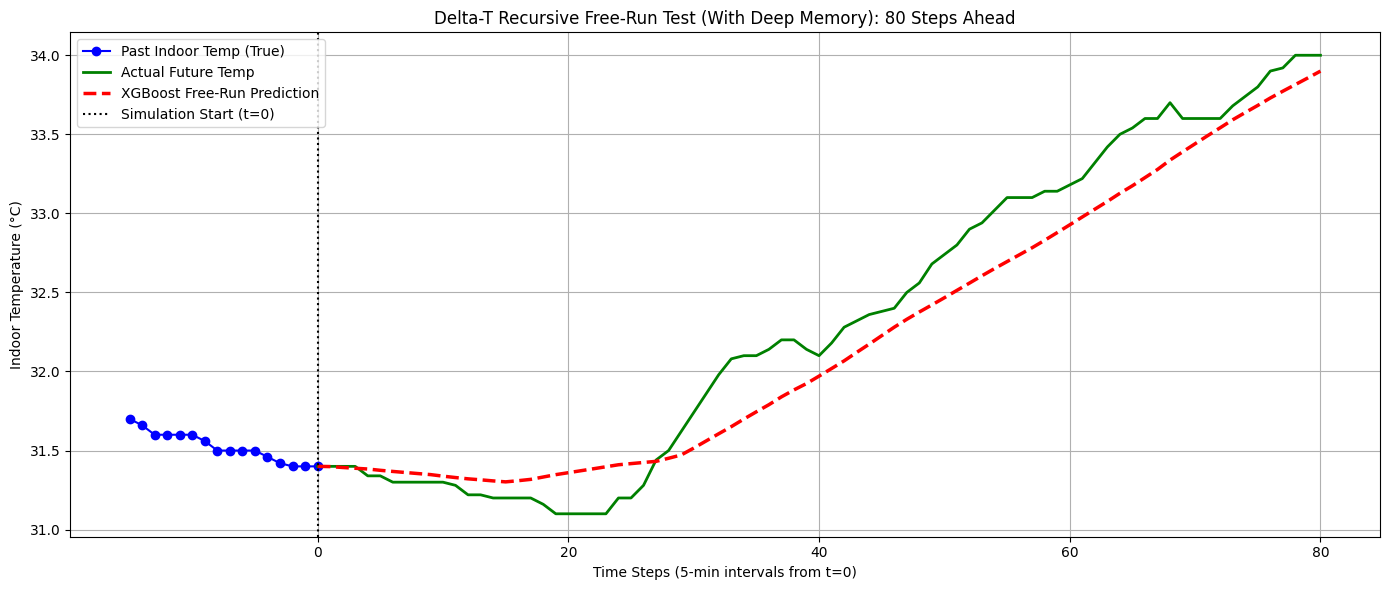

In [94]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb

# ==========================================
# 0. LOAD DATA
# ==========================================
# Use your actual real dataset
df = df_final.copy()

# Ensure Datetime is proper format and sorted chronologically
df['Datetime'] = pd.to_datetime(df['Datetime'])
df = df.sort_values('Datetime').reset_index(drop=True)

# ==========================================
# 1. PREPARE DATA FOR DELTA PREDICTION
# ==========================================
# Cyclical Time Features
df['Hour_sin'] = np.sin(2 * np.pi * df['Datetime'].dt.hour / 24)
df['Hour_cos'] = np.cos(2 * np.pi * df['Datetime'].dt.hour / 24)

# Thermodynamic drivers
df['Temp_Diff'] = df['OutdoorTemp'] - df['IndoorTemp']

# Lags & Momentum
df['IndoorTemp_Lag1'] = df['IndoorTemp'].shift(1)
df['Temp_Change_Rate'] = df['IndoorTemp'] - df['IndoorTemp_Lag1']
df['AC_State_Lag1'] = df['AC_State'].shift(1)

# 1. Short-term memory (What happened over the last hour?)
df['IndoorTemp_RollingMean_1hr'] = df['IndoorTemp'].rolling(window=12).mean()

# 2. Thermal Mass memory (How much heat soaked into the walls over the last 4 hours?)
df['OutdoorTemp_RollingMean_4hr'] = df['OutdoorTemp'].rolling(window=48).mean()

# 3. Deep Lags (What was the exact temperature exactly 1 hour ago?)
df['IndoorTemp_Lag12'] = df['IndoorTemp'].shift(12)

# THE CRITICAL FIX: The target is now the CHANGE in temperature (Delta-T)
df['Target_Delta_Next_Step'] = df['IndoorTemp'].shift(-1) - df['IndoorTemp']

# Drop NaNs caused by the shifting operations
df = df.dropna().reset_index(drop=True)

# FIX #1: Removed 'Target_Delta_Next_Step' from this list! It belongs only in 'y'
features = [
    'IndoorTemp', 'IndoorHumidity', 'OutdoorTemp', 'OutdoorHumidity',
    'Rain', 'CloudCover', 'WindSpeed', 'Temp_Diff', 'AC_State',
    'Hour_sin', 'Hour_cos', 'IndoorTemp_Lag1', 'Temp_Change_Rate', 'AC_State_Lag1',
    'IndoorTemp_RollingMean_1hr', 'OutdoorTemp_RollingMean_4hr', 'IndoorTemp_Lag12'
]

X = df[features].values
y = df['Target_Delta_Next_Step'].values # Training on Delta-T!

# Chronological Train/Test Split (80/20)
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]
df_test = df.iloc[split:].reset_index(drop=True)


# ==========================================
# 2. TRAIN AUTOREGRESSIVE XGBOOST
# ==========================================
print("Training Autoregressive XGBoost on Delta-T...")
model = xgb.XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror'
)
model.fit(X_train, y_train)

# ==========================================
# 3. RECURSIVE FREE-RUN SIMULATION (DELTA MODE)
# ==========================================
HORIZON = 80
past_context = 15

start_idx = past_context
for i in range(past_context, len(df_test) - HORIZON - 1):
    if df_test['AC_State'].iloc[i+1] == 1 and df_test['AC_State'].iloc[i] == 0:
        start_idx = i
        break

# Initialize simulation variables
current_simulated_temp = df_test['IndoorTemp'].iloc[start_idx]
current_lag1_temp = df_test['IndoorTemp_Lag1'].iloc[start_idx]
current_ac_lag1 = df_test['AC_State_Lag1'].iloc[start_idx]
constant_indoor_h = df_test['IndoorHumidity'].iloc[start_idx]

# FIX #2: We need a "Memory Buffer" of the last 12 temperatures to calculate rolling features
# We initialize it with the true past 12 steps leading up to t=0
simulated_temp_history = list(df_test['IndoorTemp'].iloc[start_idx - 11 : start_idx + 1].values)

predictions = []
actuals = df_test['IndoorTemp'].iloc[start_idx + 1 : start_idx + 1 + HORIZON].values

print(f"Starting Delta-T Free-Run Simulation for {HORIZON} steps...")

for step in range(HORIZON):
    current_idx = start_idx + step + 1

    # "Future Knowns" (Weather & AC Schedule)
    outdoor_t = df_test['OutdoorTemp'].iloc[current_idx]
    outdoor_h = df_test['OutdoorHumidity'].iloc[current_idx]
    rain = df_test['Rain'].iloc[current_idx]
    clouds = df_test['CloudCover'].iloc[current_idx]
    wind = df_test['WindSpeed'].iloc[current_idx]
    ac = df_test['AC_State'].iloc[current_idx]
    hr_sin = df_test['Hour_sin'].iloc[current_idx]
    hr_cos = df_test['Hour_cos'].iloc[current_idx]

    # We can just read the Outdoor rolling mean from the test dataset because it is future weather!
    outdoor_t_rolling_4hr = df_test['OutdoorTemp_RollingMean_4hr'].iloc[current_idx]

    # Dynamic simulated features
    temp_diff = outdoor_t - current_simulated_temp
    temp_change_rate = current_simulated_temp - current_lag1_temp

    # FIX #2 continued: Dynamically calculate Indoor Rolling Mean and Lag12 using our memory buffer
    indoor_t_rolling_1hr = np.mean(simulated_temp_history[-12:]) # Average of the last 12 predictions
    indoor_t_lag12 = simulated_temp_history[-12]                 # The prediction from exactly 12 steps ago

    # Build feature vector (Now perfectly matching the 17 features)
    X_step = np.array([[
        current_simulated_temp, constant_indoor_h, outdoor_t, outdoor_h,
        rain, clouds, wind, temp_diff, ac,
        hr_sin, hr_cos, current_lag1_temp, temp_change_rate, current_ac_lag1,
        indoor_t_rolling_1hr, outdoor_t_rolling_4hr, indoor_t_lag12
    ]])

    # Predict DELTA
    predicted_delta = model.predict(X_step)[0]
    next_temp = current_simulated_temp + predicted_delta
    predictions.append(next_temp)

    # UPDATE VARIABLES & BUFFER FOR THE NEXT LOOP
    current_lag1_temp = current_simulated_temp
    current_ac_lag1 = ac
    current_simulated_temp = next_temp
    simulated_temp_history.append(next_temp) # Add newest prediction to memory buffer


# ==========================================
# 4. VISUALIZATION
# ==========================================
plt.figure(figsize=(14, 6))

past_actuals = df_test['IndoorTemp'].iloc[start_idx - past_context : start_idx + 1].values
time_past = range(-past_context, 1)
plt.plot(time_past, past_actuals, label='Past Indoor Temp (True)', color='blue', marker='o')

time_future = range(1, HORIZON + 1)
time_pred = [0] + list(time_future)
actual_line = [past_actuals[-1]] + list(actuals)
pred_line = [past_actuals[-1]] + list(predictions)

plt.plot(time_pred, actual_line, label='Actual Future Temp', color='green', linewidth=2)
plt.plot(time_pred, pred_line, label='XGBoost Free-Run Prediction', color='red', linestyle='--', linewidth=2.5)

for t, ac_is_on in zip(time_future, df_test['AC_State'].iloc[start_idx + 1 : start_idx + 1 + HORIZON]):
    if ac_is_on == 1:
        plt.axvspan(t-0.5, t+0.5, color='cyan', alpha=0.15, lw=0)

plt.axvline(x=0, color='black', linestyle=':', label='Simulation Start (t=0)')
plt.title(f"Delta-T Recursive Free-Run Test (With Deep Memory): {HORIZON} Steps Ahead")
plt.xlabel("Time Steps (5-min intervals from t=0)")
plt.ylabel("Indoor Temperature (°C)")
plt.legend(loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()


Running Counterfactual Stress Tests...


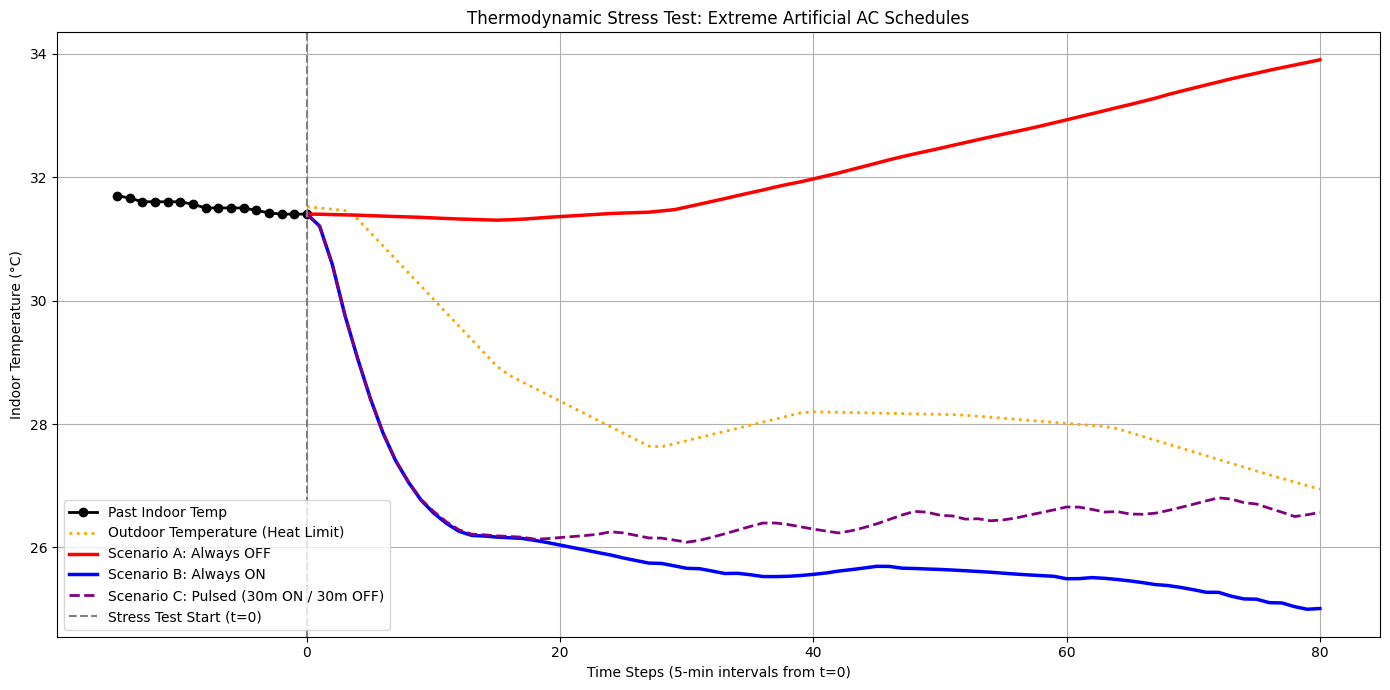

In [92]:
# ==========================================
# 5. COUNTERFACTUAL STRESS TESTING
# ==========================================
print("\nRunning Counterfactual Stress Tests...")

# Function to run the recursive loop with a custom, forced AC schedule
def simulate_scenario(model, df_test, start_idx, horizon, ac_schedule):
    # Initialize simulation variables identically to the main test
    current_simulated_temp = df_test['IndoorTemp'].iloc[start_idx]
    current_lag1_temp = df_test['IndoorTemp_Lag1'].iloc[start_idx]
    current_ac_lag1 = df_test['AC_State_Lag1'].iloc[start_idx]
    constant_indoor_h = df_test['IndoorHumidity'].iloc[start_idx]

    simulated_temp_history = list(df_test['IndoorTemp'].iloc[start_idx - 11 : start_idx + 1].values)
    predictions = []

    for step in range(horizon):
        current_idx = start_idx + step + 1
        if current_idx >= len(df_test):
            break

        # Future Knowns (Weather stays real)
        outdoor_t = df_test['OutdoorTemp'].iloc[current_idx]
        outdoor_h = df_test['OutdoorHumidity'].iloc[current_idx]
        rain = df_test['Rain'].iloc[current_idx]
        clouds = df_test['CloudCover'].iloc[current_idx]
        wind = df_test['WindSpeed'].iloc[current_idx]
        hr_sin = df_test['Hour_sin'].iloc[current_idx]
        hr_cos = df_test['Hour_cos'].iloc[current_idx]
        outdoor_t_rolling_4hr = df_test['OutdoorTemp_RollingMean_4hr'].iloc[current_idx]

        # ---> THE STRESS TEST OVERRIDE <---
        # Force the model to use our hypothetical AC state instead of reality
        ac = ac_schedule[step]

        # Dynamic simulated features
        temp_diff = outdoor_t - current_simulated_temp
        temp_change_rate = current_simulated_temp - current_lag1_temp
        indoor_t_rolling_1hr = np.mean(simulated_temp_history[-12:])
        indoor_t_lag12 = simulated_temp_history[-12]

        # Build feature vector
        X_step = np.array([[
            current_simulated_temp, constant_indoor_h, outdoor_t, outdoor_h,
            rain, clouds, wind, temp_diff, ac,
            hr_sin, hr_cos, current_lag1_temp, temp_change_rate, current_ac_lag1,
            indoor_t_rolling_1hr, outdoor_t_rolling_4hr, indoor_t_lag12
        ]])

        # Predict DELTA and update
        predicted_delta = model.predict(X_step)[0]
        next_temp = current_simulated_temp + predicted_delta
        predictions.append(next_temp)

        # Update for next loop
        current_lag1_temp = current_simulated_temp
        current_ac_lag1 = ac
        current_simulated_temp = next_temp
        simulated_temp_history.append(next_temp)

    return predictions

# --- Define the 3 Extreme Scenarios ---
STRESS_HORIZON = 80 # Approx 6.5 hours (assuming 5 min intervals)

# Scenario A: AC is broken, stays OFF entirely
schedule_off = [0] * STRESS_HORIZON

# Scenario B: AC is left running at maximum, stays ON entirely
schedule_on = [1] * STRESS_HORIZON

# Scenario C: AC pulses ON for 30 mins (6 steps), OFF for 30 mins (6 steps)
schedule_pulse = [1 if (i // 6) % 2 == 0 else 0 for i in range(STRESS_HORIZON)]

# Run the simulations
pred_off = simulate_scenario(model, df_test, start_idx, STRESS_HORIZON, schedule_off)
pred_on = simulate_scenario(model, df_test, start_idx, STRESS_HORIZON, schedule_on)
pred_pulse = simulate_scenario(model, df_test, start_idx, STRESS_HORIZON, schedule_pulse)

# Grab actual outdoor temp to verify physical boundaries
outdoor_temps = df_test['OutdoorTemp'].iloc[start_idx + 1 : start_idx + 1 + STRESS_HORIZON].values

# --- Visualization of the Stress Test ---
plt.figure(figsize=(14, 7))

# Setup timeline
time_past = range(-past_context, 1)
time_future = range(1, STRESS_HORIZON + 1)
time_pred = [0] + list(time_future)

# Past actuals for visual anchor
past_actuals = df_test['IndoorTemp'].iloc[start_idx - past_context : start_idx + 1].values
plt.plot(time_past, past_actuals, label='Past Indoor Temp', color='black', marker='o', linewidth=2)

# Prepare trajectories connecting to t=0
line_off = [past_actuals[-1]] + pred_off
line_on = [past_actuals[-1]] + pred_on
line_pulse = [past_actuals[-1]] + pred_pulse
line_outdoor = [df_test['OutdoorTemp'].iloc[start_idx]] + list(outdoor_temps)

# Plot Scenarios
plt.plot(time_pred, line_outdoor, label='Outdoor Temperature (Heat Limit)', color='orange', linestyle=':', linewidth=2)
plt.plot(time_pred, line_off, label='Scenario A: Always OFF', color='red', linestyle='-', linewidth=2.5)
plt.plot(time_pred, line_on, label='Scenario B: Always ON', color='blue', linestyle='-', linewidth=2.5)
plt.plot(time_pred, line_pulse, label='Scenario C: Pulsed (30m ON / 30m OFF)', color='purple', linestyle='--', linewidth=2)

plt.axvline(x=0, color='grey', linestyle='--', label='Stress Test Start (t=0)')
plt.title("Thermodynamic Stress Test: Extreme Artificial AC Schedules")
plt.xlabel("Time Steps (5-min intervals from t=0)")
plt.ylabel("Indoor Temperature (°C)")
plt.legend(loc='lower left')
plt.grid(True)
plt.tight_layout()
plt.show()

In [95]:
import json
features = [
    'IndoorTemp', 'IndoorHumidity', 'OutdoorTemp', 'OutdoorHumidity',
    'Rain', 'CloudCover', 'WindSpeed', 'Temp_Diff', 'AC_State',
    'Hour_sin', 'Hour_cos', 'IndoorTemp_Lag1', 'Temp_Change_Rate', 'AC_State_Lag1',
    'IndoorTemp_RollingMean_1hr', 'OutdoorTemp_RollingMean_4hr', 'IndoorTemp_Lag12'
]

# Save the feature names order
with open('model_features.json', 'w') as f:
    json.dump(features, f)

model.save_model('xgboost_delta_t_model.json')
print("Model successfully saved to 'xgboost_delta_t_model.json'")

Model successfully saved to 'xgboost_delta_t_model.json'


## Archive

Training Dual-Input Digital Twin...
Epoch 1/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.1772 - val_loss: 0.1320
Epoch 2/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1057 - val_loss: 0.0797
Epoch 3/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0631 - val_loss: 0.0467
Epoch 4/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0367 - val_loss: 0.0265
Epoch 5/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0209 - val_loss: 0.0146
Epoch 6/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0117 - val_loss: 0.0078
Epoch 7/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0065 - val_loss: 0.0041
Epoch 8/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0037 - val_loss: 0.0021
Epoch 9/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0022 - val_loss: 0.0011
Epoch 10/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0014 - val_loss: 5.6783e-04
Epoch 11/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0010 - val_loss: 3.5924e-04
Epoch 12/50
45/45 ━━━━━━━━━━━

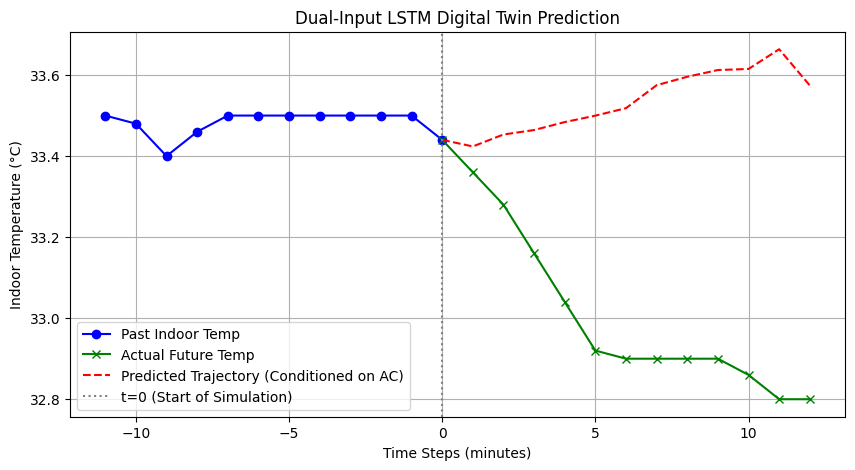

In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Model
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input, Concatenate, Flatten
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import regularizers

df = df_final.copy()

df = df.sort_values('Datetime').reset_index(drop=True)
df['Hour_sin'] = np.sin(2 * np.pi * df['Datetime'].dt.hour / 24)
df['Hour_cos'] = np.cos(2 * np.pi * df['Datetime'].dt.hour / 24)

# We now split our features into "Past" (everything) and "Future" (only what we know/control)
past_features = [
    'IndoorTemp', 'IndoorHumidity', 'OutdoorTemp', 'OutdoorHumidity',
    'AC_State', 'WindSpeed', 'CloudCover', 'Hour_sin', 'Hour_cos'
]

# We cannot feed future IndoorTemp/Humidity because that is what we are trying to predict!
future_features = [
    'OutdoorTemp', 'OutdoorHumidity', 'AC_State',
    'WindSpeed', 'CloudCover', 'Hour_sin', 'Hour_cos'
]

# Create separate scalers
scaler_past = MinMaxScaler()
data_past_scaled = scaler_past.fit_transform(df[past_features].values)

scaler_future = MinMaxScaler()
data_future_scaled = scaler_future.fit_transform(df[future_features].values)

target_idx = past_features.index('IndoorTemp')
scaler_y = MinMaxScaler()
scaler_y.fit(df[['IndoorTemp']])

# ==========================================
# 2. CREATE DUAL-INPUT SEQUENCES
# ==========================================
LOOKBACK = 12
HORIZON = 12

def create_dual_sequences(past_data, future_data, target_idx, lookback, horizon):
    X_past, X_future, y_delta = [], [], []

    for i in range(len(past_data) - lookback - horizon):
        # 1. The past 12 minutes (all variables)
        X_past.append(past_data[i : i + lookback])

        # 2. The next 12 minutes (ONLY control and weather variables)
        X_future.append(future_data[i + lookback : i + lookback + horizon])

        # 3. The target: Delta T (Future absolute temps minus Anchor temp)
        anchor_temp = past_data[i + lookback - 1, target_idx]
        future_temps = past_data[i + lookback : i + lookback + horizon, target_idx]
        delta_t = future_temps - anchor_temp
        y_delta.append(delta_t)

    return np.array(X_past), np.array(X_future), np.array(y_delta)

X_past, X_future, y = create_dual_sequences(
    data_past_scaled, data_future_scaled, target_idx, LOOKBACK, HORIZON
)

# Train/Test Split (No shuffling for time-series)
split = int(0.8 * len(X_past))
X_past_train, X_past_test = X_past[:split], X_past[split:]
X_future_train, X_future_test = X_future[:split], X_future[split:]
y_train, y_test = y[:split], y[split:]

# ==========================================
# 3. BUILD THE DUAL-INPUT MODEL
# ==========================================
# Input Branch 1: The Past (LSTM)
past_input = Input(shape=(LOOKBACK, len(past_features)), name="Past_Context")
lstm_out = LSTM(64, activation='relu', return_sequences=False)(past_input)
lstm_out = Dropout(0.2)(lstm_out)

# Input Branch 2: The Future Plan (Dense)
future_input = Input(shape=(HORIZON, len(future_features)), name="Future_Plan")
future_flat = Flatten()(future_input) # Flatten the 2D future matrix into a 1D vector

# Combine both branches
merged = Concatenate()([lstm_out, future_flat])

# Dense layers to interpret the combined context
dense1 = Dense(64, activation='relu')(merged)
# Output Layer with L2 Regularization to keep the curve smooth
output = Dense(HORIZON, kernel_regularizer=regularizers.l2(0.01), name="Delta_T_Output")(dense1)

model = Model(inputs=[past_input, future_input], outputs=output)
model.compile(optimizer='adam', loss='huber')

print("Training Dual-Input Digital Twin...")
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    [X_past_train, X_future_train], y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

# ==========================================
# 4. SIMULATE AND VISUALIZE
# ==========================================
# Grab a test sample
test_idx = 150
sample_past = X_past_test[test_idx:test_idx+1]
sample_future = X_future_test[test_idx:test_idx+1]

# Predict the Delta-T
predicted_delta_scaled = model.predict([sample_past, sample_future])[0]
actual_delta_scaled = y_test[test_idx]

# Anchor Temp Extraction (from the last step of the past input)
anchor_temp_scaled = sample_past[0, -1, target_idx]

# Reconstruct Absolute Temperatures
predicted_future_scaled = anchor_temp_scaled + predicted_delta_scaled
actual_future_scaled = anchor_temp_scaled + actual_delta_scaled

# Inverse Transform
predicted_future = scaler_y.inverse_transform(predicted_future_scaled.reshape(-1, 1)).flatten()
actual_future = scaler_y.inverse_transform(actual_future_scaled.reshape(-1, 1)).flatten()
past_temps = scaler_y.inverse_transform(sample_past[0, :, target_idx].reshape(-1, 1)).flatten()

# --- Plotting ---
plt.figure(figsize=(10, 5))

time_past = range(-LOOKBACK + 1, 1)
plt.plot(time_past, past_temps, label='Past Indoor Temp', color='blue', marker='o')

time_future = range(1, HORIZON + 1)
time_pred = [0] + list(time_future)
actual_line = [past_temps[-1]] + list(actual_future)
pred_line = [past_temps[-1]] + list(predicted_future)

plt.plot(time_pred, actual_line, label='Actual Future Temp', color='green', marker='x')
plt.plot(time_pred, pred_line, label='Predicted Trajectory (Conditioned on AC)', color='red', linestyle='--')

plt.axvline(x=0, color='grey', linestyle=':', label='t=0 (Start of Simulation)')
plt.title("Dual-Input LSTM Digital Twin Prediction")
plt.xlabel("Time Steps (minutes)")
plt.ylabel("Indoor Temperature (°C)")
plt.legend()
plt.grid(True)
plt.show()

Encoder-Decoder LSTM

Training Encoder-Decoder Digital Twin...
Epoch 1/60
45/45 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - loss: 0.1173 - val_loss: 0.0032
Epoch 2/60
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0282 - val_loss: 0.0015
Epoch 3/60
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0146 - val_loss: 5.4327e-04
Epoch 4/60
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0071 - val_loss: 3.2162e-04
Epoch 5/60
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0030 - val_loss: 3.0686e-04
Epoch 6/60
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0013 - val_loss: 1.7423e-04
Epoch 7/60
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 6.4782e-04 - val_loss: 1.2577e-04
Epoch 8/60
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 3.9456e-04 - val_loss: 5.2616e-04
Epoch 9/60
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 2.8642e-04 - val_loss: 8.6302e-05
Epoch 10/60
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 1.9636e-04 - val_loss: 6.0942e-05
Epoch 11/60
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.5170e-0

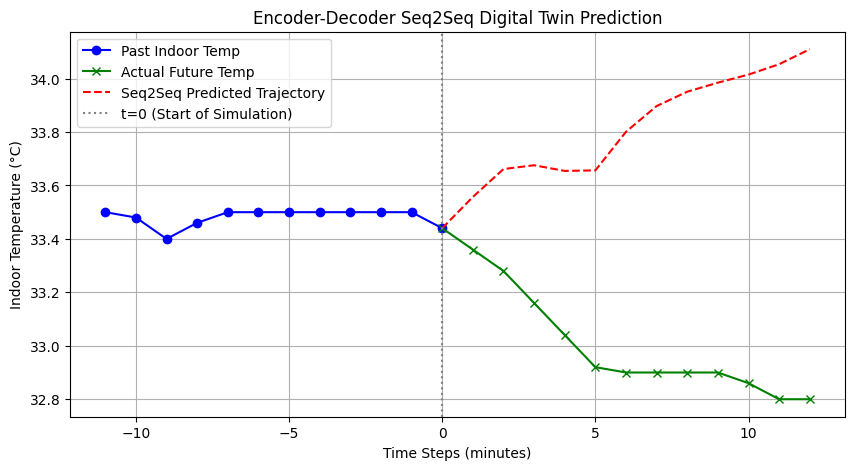

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Model
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input, TimeDistributed, Concatenate, Add, Lambda, Subtract
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.constraints import NonNeg

# ==========================================
# 1. DATA PREPARATION
# ==========================================
df = df_final.copy()

df = df.sort_values('Datetime').reset_index(drop=True)
df['Hour_sin'] = np.sin(2 * np.pi * df['Datetime'].dt.hour / 24)
df['Hour_cos'] = np.cos(2 * np.pi * df['Datetime'].dt.hour / 24)
df['Temp_Diff'] = df['OutdoorTemp'] - df['IndoorTemp']

# The AC amplifiers (Interaction terms)
df['AC_Cooling_Drive_Past'] = df['AC_State'] * df['IndoorTemp']
df['AC_Cooling_Drive_Future'] = df['AC_State'] * df['OutdoorTemp']

past_features = [
    'IndoorTemp', 'IndoorHumidity', 'OutdoorTemp', 'OutdoorHumidity',
    'AC_State', 'WindSpeed', 'CloudCover', 'Hour_sin', 'Hour_cos',
    'Temp_Diff', 'AC_Cooling_Drive_Past' # <-- NEW FEATURES INJECTED HERE
]

future_features = [
    'OutdoorTemp', 'OutdoorHumidity', 'AC_State',
    'WindSpeed', 'CloudCover', 'Hour_sin', 'Hour_cos',
    'AC_Cooling_Drive_Future' # <-- NEW FEATURE INJECTED HERE
]

scaler_past = MinMaxScaler()
data_past_scaled = scaler_past.fit_transform(df[past_features].values)

scaler_future = MinMaxScaler()
data_future_scaled = scaler_future.fit_transform(df[future_features].values)

target_idx = past_features.index('IndoorTemp')
scaler_y = MinMaxScaler()
scaler_y.fit(df[['IndoorTemp']])

# ==========================================
# 2. CREATE SEQ2SEQ SEQUENCES
# ==========================================
LOOKBACK = 12
HORIZON = 12

def create_derivative_sequences(past_data, future_data, target_idx, lookback, horizon):
    X_past, X_future, y_step_diff = [], [], []

    for i in range(len(past_data) - lookback - horizon):
        X_past.append(past_data[i : i + lookback])
        X_future.append(future_data[i + lookback : i + lookback + horizon])

        anchor_temp = past_data[i + lookback - 1, target_idx]
        future_temps = past_data[i + lookback : i + lookback + horizon, target_idx]

        # THE FIX: Calculate minute-to-minute changes (dT/dt)
        # We insert the anchor at the beginning so the first diff is (Step 1 - Anchor)
        all_temps = np.insert(future_temps, 0, anchor_temp)
        step_diffs = np.diff(all_temps)

        y_step_diff.append(step_diffs.reshape(horizon, 1))

    return np.array(X_past), np.array(X_future), np.array(y_step_diff)

# Re-create your sequences with the new function
X_past, X_future, y = create_derivative_sequences(
    data_past_scaled, data_future_scaled, target_idx, LOOKBACK, HORIZON
)

split = int(0.8 * len(X_past))
X_past_train, X_past_test = X_past[:split], X_past[split:]
X_future_train, X_future_test = X_future[:split], X_future[split:]
y_train, y_test = y[:split], y[split:]

# ==========================================
# 3. BUILD THE ENCODER-DECODER MODEL
# ==========================================
# --- ENCODER ---
encoder_inputs = Input(shape=(LOOKBACK, len(past_features)), name="Past_Encoder_Input")
encoder_lstm = LSTM(64, return_state=True, name="Encoder_LSTM")
encoder_outputs, state_h, state_c = encoder_lstm(encoder_inputs)
encoder_states = [state_h, state_c]

# --- DECODER ---
decoder_inputs = Input(shape=(HORIZON, len(future_features)), name="Future_Decoder_Input")
decoder_lstm = LSTM(64, return_sequences=True, return_state=True, name="Decoder_LSTM")
decoder_outputs, _, _ = decoder_lstm(decoder_inputs, initial_state=encoder_states)

# ==========================================
# THE HYBRID SPLIT
# ==========================================
# BRANCH 1: The LSTM predicts the natural weather/room drift
weather_drift = TimeDistributed(Dense(1, name="Natural_Weather_Drift"))(decoder_outputs)

# BRANCH 2: Extract ONLY the AC_State from the future inputs
ac_only = Lambda(lambda x: x[:, :, 2:3], name="Extract_AC_State")(decoder_inputs)

# We use NonNeg to force the AC to have a POSITIVE mathematical weight...
cooling_effect = TimeDistributed(
    Dense(1, kernel_constraint=NonNeg(), use_bias=False, name="Explicit_Cooling")
)(ac_only)

# ...and then we explicitly SUBTRACT it from the weather drift.
# This mathematically guarantees the AC can only lower the temperature.
output = Subtract(name="Final_Delta_T")([weather_drift, cooling_effect])

model = Model(inputs=[encoder_inputs, decoder_inputs], outputs=output)
model.compile(optimizer='adam', loss='mse')
print("Training Encoder-Decoder Digital Twin...")
early_stop = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)

history = model.fit(
    [X_past_train, X_future_train], y_train,
    epochs=60, # Increased slightly to allow the complex architecture to learn
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

# ==========================================
# 4. SIMULATE AND VISUALIZE
# ==========================================
test_idx = 150
sample_past = X_past_test[test_idx:test_idx+1]
sample_future = X_future_test[test_idx:test_idx+1]

# The prediction now outputs shape (1, HORIZON, 1)
predicted_step_diffs_scaled = model.predict([sample_past, sample_future])[0].flatten()
actual_step_diffs_scaled = y_test[test_idx].flatten()

anchor_temp_scaled = sample_past[0, -1, target_idx]

# 2. THE FIX: Cumulatively sum the differences to build a continuous trajectory
predicted_delta_scaled = np.cumsum(predicted_step_diffs_scaled)
actual_delta_scaled = np.cumsum(actual_step_diffs_scaled)

# 3. Add to the anchor to get absolute scaled temperatures
predicted_future_scaled = anchor_temp_scaled + predicted_delta_scaled
actual_future_scaled = anchor_temp_scaled + actual_delta_scaled

# Inverse transform to Celsius
predicted_future = scaler_y.inverse_transform(predicted_future_scaled.reshape(-1, 1)).flatten()
actual_future = scaler_y.inverse_transform(actual_future_scaled.reshape(-1, 1)).flatten()
past_temps = scaler_y.inverse_transform(sample_past[0, :, target_idx].reshape(-1, 1)).flatten()

# --- Plotting ---
plt.figure(figsize=(10, 5))
time_past = range(-LOOKBACK + 1, 1)
plt.plot(time_past, past_temps, label='Past Indoor Temp', color='blue', marker='o')

time_future = range(1, HORIZON + 1)
time_pred = [0] + list(time_future)
actual_line = [past_temps[-1]] + list(actual_future)
pred_line = [past_temps[-1]] + list(predicted_future)

plt.plot(time_pred, actual_line, label='Actual Future Temp', color='green', marker='x')
plt.plot(time_pred, pred_line, label='Seq2Seq Predicted Trajectory', color='red', linestyle='--')

plt.axvline(x=0, color='grey', linestyle=':', label='t=0 (Start of Simulation)')
plt.title("Encoder-Decoder Seq2Seq Digital Twin Prediction")
plt.xlabel("Time Steps (minutes)")
plt.ylabel("Indoor Temperature (°C)")
plt.legend()
plt.grid(True)
plt.show()

Back to baseline

Training Conditioned Direct Multi-Step Digital Twin...
Epoch 1/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.1843 - val_loss: 0.1407
Epoch 2/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1223 - val_loss: 0.0985
Epoch 3/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0852 - val_loss: 0.0679
Epoch 4/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0587 - val_loss: 0.0460
Epoch 5/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0399 - val_loss: 0.0306
Epoch 6/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0269 - val_loss: 0.0200
Epoch 7/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0180 - val_loss: 0.0129
Epoch 8/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0121 - val_loss: 0.0082
Epoch 9/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0082 - val_loss: 0.0051
Epoch 10/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0056 - val_loss: 0.0032
Epoch 11/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0040 - val_loss: 0.0020
Epoch 12/50
45/45 

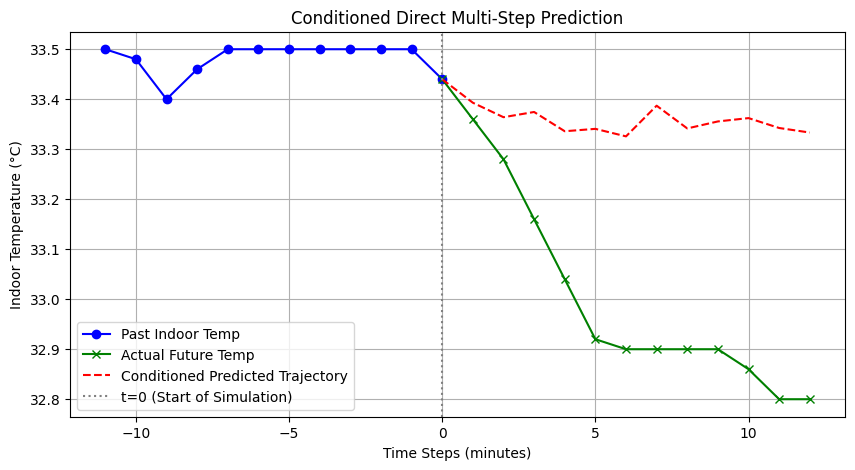

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Model
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input, Concatenate
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import regularizers

# ==========================================
# 1. DATA PREPARATION (Back to Basics)
# ==========================================
df = df_final.copy()
df = df.sort_values('Datetime').reset_index(drop=True)
df['Hour_sin'] = np.sin(2 * np.pi * df['Datetime'].dt.hour / 24)
df['Hour_cos'] = np.cos(2 * np.pi * df['Datetime'].dt.hour / 24)

# Keep the Temp_Diff, it's good physics practice
df['Temp_Diff'] = df['OutdoorTemp'] - df['IndoorTemp']

features = [
    'IndoorTemp', 'IndoorHumidity', 'OutdoorTemp', 'OutdoorHumidity',
    'AC_State', 'WindSpeed', 'CloudCover', 'Hour_sin', 'Hour_cos', 'Temp_Diff'
]

data = df[features].values
scaler_X = MinMaxScaler()
data_scaled = scaler_X.fit_transform(data)

target_idx = features.index('IndoorTemp')
ac_idx = features.index('AC_State')

scaler_y = MinMaxScaler()
scaler_y.fit(df[['IndoorTemp']])

# ==========================================
# 2. CREATE CONDITIONED SEQUENCES
# ==========================================
LOOKBACK = 12
HORIZON = 12

def create_conditioned_sequences(data, target_idx, ac_idx, lookback, horizon):
    X_past, X_future_ac, y_delta = [], [], []
    for i in range(len(data) - lookback - horizon):
        # 1. Past 12 minutes of ALL variables
        X_past.append(data[i : i + lookback])

        # 2. Future 12 minutes of ONLY the AC_State
        X_future_ac.append(data[i + lookback : i + lookback + horizon, ac_idx])

        # 3. Target: The Delta T trajectory (Future Temp - Anchor Temp)
        anchor_temp = data[i + lookback - 1, target_idx]
        future_temps = data[i + lookback : i + lookback + horizon, target_idx]
        y_delta.append(future_temps - anchor_temp)

    return np.array(X_past), np.array(X_future_ac), np.array(y_delta)

X_past, X_future_ac, y = create_conditioned_sequences(
    data_scaled, target_idx, ac_idx, LOOKBACK, HORIZON
)

split = int(0.8 * len(X_past))
X_past_train, X_past_test = X_past[:split], X_past[split:]
X_ac_train, X_ac_test = X_future_ac[:split], X_future_ac[split:]
y_train, y_test = y[:split], y[split:]

# ==========================================
# 3. BUILD THE CONDITIONED MULTI-STEP MODEL
# ==========================================
# Branch 1: Read the past
past_input = Input(shape=(LOOKBACK, len(features)), name="Past_Context")
lstm_out = LSTM(64, activation='relu')(past_input)
lstm_out = Dropout(0.2)(lstm_out)

# Branch 2: Read the future AC plan (Already flat, shape is just HORIZON)
future_ac_input = Input(shape=(HORIZON,), name="Future_AC_Plan")

# Merge them together
merged = Concatenate()([lstm_out, future_ac_input])

# Dense processing
dense1 = Dense(32, activation='relu')(merged)

# Output: Direct Multi-Step trajectory with L2 smoothing (like the first model)
output = Dense(HORIZON, kernel_regularizer=regularizers.l2(0.01))(dense1)

model = Model(inputs=[past_input, future_ac_input], outputs=output)
model.compile(optimizer='adam', loss='mse')

print("Training Conditioned Direct Multi-Step Digital Twin...")
early_stop = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)

history = model.fit(
    [X_past_train, X_ac_train], y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

# ==========================================
# 4. SIMULATE AND VISUALIZE
# ==========================================
test_idx = 150
sample_past = X_past_test[test_idx:test_idx+1]
sample_ac = X_ac_test[test_idx:test_idx+1]

# Predict directly (no cumsum, no loops)
predicted_delta_scaled = model.predict([sample_past, sample_ac])[0]
actual_delta_scaled = y_test[test_idx]

anchor_temp_scaled = sample_past[0, -1, target_idx]

# Reconstruct
predicted_future_scaled = anchor_temp_scaled + predicted_delta_scaled
actual_future_scaled = anchor_temp_scaled + actual_delta_scaled

predicted_future = scaler_y.inverse_transform(predicted_future_scaled.reshape(-1, 1)).flatten()
actual_future = scaler_y.inverse_transform(actual_future_scaled.reshape(-1, 1)).flatten()
past_temps = scaler_y.inverse_transform(sample_past[0, :, target_idx].reshape(-1, 1)).flatten()

# --- Plotting ---
plt.figure(figsize=(10, 5))
time_past = range(-LOOKBACK + 1, 1)
plt.plot(time_past, past_temps, label='Past Indoor Temp', color='blue', marker='o')

time_future = range(1, HORIZON + 1)
time_pred = [0] + list(time_future)
actual_line = [past_temps[-1]] + list(actual_future)
pred_line = [past_temps[-1]] + list(predicted_future)

plt.plot(time_pred, actual_line, label='Actual Future Temp', color='green', marker='x')
plt.plot(time_pred, pred_line, label='Conditioned Predicted Trajectory', color='red', linestyle='--')

plt.axvline(x=0, color='grey', linestyle=':', label='t=0 (Start of Simulation)')
plt.title("Conditioned Direct Multi-Step Prediction")
plt.xlabel("Time Steps (minutes)")
plt.ylabel("Indoor Temperature (°C)")
plt.legend()
plt.grid(True)
plt.show()

Training Delta-T model...
Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


45/45 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - loss: 0.1664 - val_loss: 0.1248
Epoch 2/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0987 - val_loss: 0.0734
Epoch 3/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0577 - val_loss: 0.0420
Epoch 4/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0329 - val_loss: 0.0232
Epoch 5/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0183 - val_loss: 0.0124
Epoch 6/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0101 - val_loss: 0.0064
Epoch 7/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0056 - val_loss: 0.0032
Epoch 8/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0032 - val_loss: 0.0016
Epoch 9/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0019 - val_loss: 7.6651e-04
Epoch 10/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0013 - val_loss: 3.8520e-04
Epoch 11/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 9.8978e-04 - val_loss: 2.1385e-04
Epoch 12/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 8.6995e-0

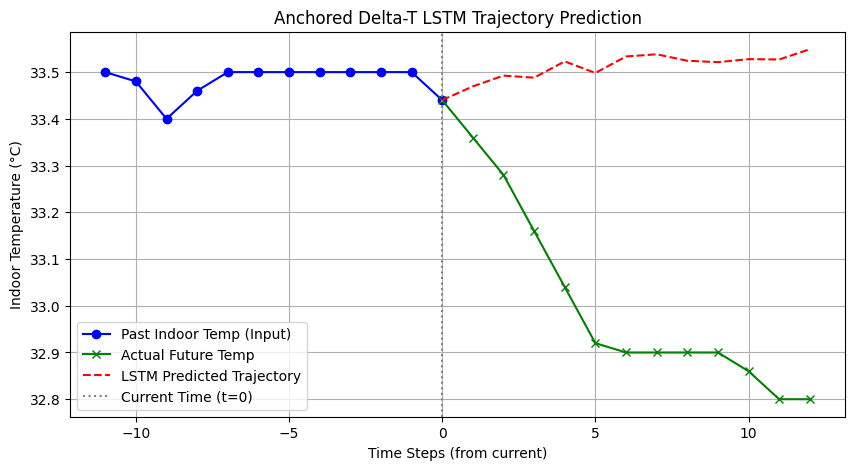

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import regularizers

# ==========================================
# 1. LOAD AND PREPARE DATA
# ==========================================
df = df_final.copy()
df = df.sort_values('Datetime').reset_index(drop=True)

# Time-of-day cyclical encoding
df['Hour_sin'] = np.sin(2 * np.pi * df['Datetime'].dt.hour / 24)
df['Hour_cos'] = np.cos(2 * np.pi * df['Datetime'].dt.hour / 24)

features = [
    'IndoorTemp', 'IndoorHumidity', 'OutdoorTemp', 'OutdoorHumidity',
    'AC_State', 'WindSpeed', 'CloudCover', 'Hour_sin', 'Hour_cos'
]
data = df[features].values

# Scale the data
scaler_X = MinMaxScaler()
data_scaled = scaler_X.fit_transform(data)

# Separate scaler for target reconstruction
target_idx = features.index('IndoorTemp')
scaler_y = MinMaxScaler()
scaler_y.fit(df[['IndoorTemp']])

# ==========================================
# 2. CREATE DELTA-T SEQUENCES (The Core Fix)
# ==========================================
LOOKBACK = 12
HORIZON = 12

def create_delta_sequences(data, target_idx, lookback, horizon):
    X, y = [], []
    for i in range(len(data) - lookback - horizon):
        X.append(data[i : i + lookback])

        # ANCHOR POINT: The exact temperature at t=0
        anchor_temp = data[i + lookback - 1, target_idx]

        # THE TARGET: The future temperatures
        future_temps = data[i + lookback : i + lookback + horizon, target_idx]

        # THE FIX: Model learns the DELTA (change) from the anchor, not the absolute temp
        delta_t = future_temps - anchor_temp
        y.append(delta_t)

    return np.array(X), np.array(y)

X, y = create_delta_sequences(data_scaled, target_idx, LOOKBACK, HORIZON)

# Time Series Split (No shuffling)
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# ==========================================
# 3. BUILD AND TRAIN THE LSTM (With Regularization)
# ==========================================
model = Sequential([
    LSTM(64, activation='relu', input_shape=(LOOKBACK, len(features))),
    Dropout(0.2),
    # THE FIX: L2 Regularization penalizes "noisy" or zigzagging predictions
    Dense(HORIZON, kernel_regularizer=regularizers.l2(0.01))
])

# Use Huber loss or MSE. Huber is often better for ignoring sudden sensor noise.
model.compile(optimizer='adam', loss='huber')

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

print("Training Delta-T model...")
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

# ==========================================
# 4. SIMULATE AND RECONSTRUCT PREDICTION
# ==========================================
# Select a test sample
test_idx = 150
input_sequence = X_test[test_idx].reshape(1, LOOKBACK, len(features))

# 1. Get the Anchor Temperature at t=0 (in scaled format)
anchor_temp_scaled = input_sequence[0, -1, target_idx]

# 2. Predict the Delta T trajectory
predicted_delta_scaled = model.predict(input_sequence)[0]

# 3. Reconstruct absolute temperatures: Anchor + Delta
predicted_future_scaled = anchor_temp_scaled + predicted_delta_scaled

# 4. Do the same for the actual target to compare
actual_delta_scaled = y_test[test_idx]
actual_future_scaled = anchor_temp_scaled + actual_delta_scaled

# Inverse transform back to Celsius
predicted_future = scaler_y.inverse_transform(predicted_future_scaled.reshape(-1, 1)).flatten()
actual_future = scaler_y.inverse_transform(actual_future_scaled.reshape(-1, 1)).flatten()

# --- Visualization ---
plt.figure(figsize=(10, 5))

# Plot past context
past_temps = scaler_y.inverse_transform(input_sequence[0, :, target_idx].reshape(-1, 1)).flatten()
time_past = range(-LOOKBACK + 1, 1) # Shifted so t=0 is the last past point
plt.plot(time_past, past_temps, label='Past Indoor Temp (Input)', color='blue', marker='o')

# Plot actual vs predicted future
# Start time_future from 1 to HORIZON, but we visually connect it from t=0
time_future = range(1, HORIZON + 1)

# To make the lines connect seamlessly on the graph, prepend the t=0 anchor point
time_pred = [0] + list(time_future)
actual_line = [past_temps[-1]] + list(actual_future)
pred_line = [past_temps[-1]] + list(predicted_future)

plt.plot(time_pred, actual_line, label='Actual Future Temp', color='green', marker='x')
plt.plot(time_pred, pred_line, label='LSTM Predicted Trajectory', color='red', linestyle='--')

plt.axvline(x=0, color='grey', linestyle=':', label='Current Time (t=0)')
plt.title("Anchored Delta-T LSTM Trajectory Prediction")
plt.xlabel("Time Steps (from current)")
plt.ylabel("Indoor Temperature (°C)")
plt.legend()
plt.grid(True)
plt.show()

Training Multi-Input Delta-T model...
Epoch 1/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - loss: 0.0066 - val_loss: 3.2844e-04
Epoch 2/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0015 - val_loss: 1.5192e-04
Epoch 3/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0011 - val_loss: 1.1961e-04
Epoch 4/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 9.1762e-04 - val_loss: 8.3400e-05
Epoch 5/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 8.5519e-04 - val_loss: 7.9828e-05
Epoch 6/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 8.1204e-04 - val_loss: 7.1832e-05
Epoch 7/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 7.3611e-04 - val_loss: 6.4883e-05
Epoch 8/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 7.0159e-04 - val_loss: 7.7415e-05
Epoch 9/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.6711e-04 - val_loss: 7.8158e-05
Epoch 10/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.1655e-04 - val_loss: 9.1824e-05
Epoch 11/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step -

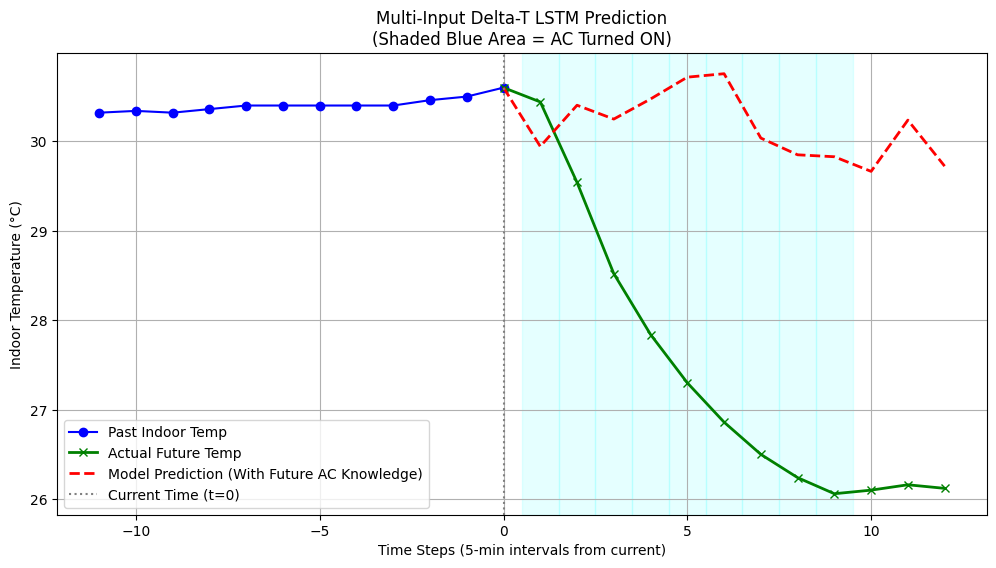

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout, Concatenate, Flatten
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping

df = df_final.copy()

# ==========================================
# 1. FEATURE ENGINEERING & PREPARATION
# ==========================================
df = df.sort_values('Datetime').reset_index(drop=True)

# Time-of-day cyclical encoding
df['Hour_sin'] = np.sin(2 * np.pi * df['Datetime'].dt.hour / 24)
df['Hour_cos'] = np.cos(2 * np.pi * df['Datetime'].dt.hour / 24)

# Physics-Informed Feature: The temperature differential
df['Temp_Diff'] = df['OutdoorTemp'] - df['IndoorTemp']

# Define the features for the PAST context and FUTURE knowns
all_features = [
    'IndoorTemp', 'IndoorHumidity', 'OutdoorTemp', 'OutdoorHumidity',
    'Temp_Diff', 'WindSpeed', 'CloudCover', 'Hour_sin', 'Hour_cos', 'AC_State'
]

# These are the variables we know for the future (AC Schedule + Time)
future_known_features = ['AC_State', 'Hour_sin', 'Hour_cos']

data = df[all_features].values

# Scale the data
scaler_X = MinMaxScaler()
data_scaled = scaler_X.fit_transform(data)

# Separate scaler for target reconstruction
target_idx = all_features.index('IndoorTemp')
scaler_y = MinMaxScaler()
scaler_y.fit(df[['IndoorTemp']])

# Get indices of future known features to extract them easily later
future_indices = [all_features.index(f) for f in future_known_features]

# ==========================================
# 2. CREATE MULTI-INPUT SEQUENCES
# ==========================================
LOOKBACK = 12
HORIZON = 12

def create_sequences_with_future(data, target_idx, future_indices, lookback, horizon):
    X_past, X_future, y_delta = [], [], []

    for i in range(len(data) - lookback - horizon + 1):
        # 1. Past Context: All features from t-12 to t=0
        X_past.append(data[i : i + lookback, :])

        # 2. Future Knowns: Only AC_State and Time from t+1 to t+12
        X_future.append(data[i + lookback : i + lookback + horizon, future_indices])

        # 3. Target: Delta-T (Future Temp - Anchor Temp)
        anchor_temp = data[i + lookback - 1, target_idx]
        future_temps = data[i + lookback : i + lookback + horizon, target_idx]
        y_delta.append(future_temps - anchor_temp)

    return np.array(X_past), np.array(X_future), np.array(y_delta)

X_past, X_future, y = create_sequences_with_future(data_scaled, target_idx, future_indices, LOOKBACK, HORIZON)

# Time Series Split (No shuffling to avoid data leakage)
split = int(0.8 * len(X_past))
X_past_train, X_past_test = X_past[:split], X_past[split:]
X_future_train, X_future_test = X_future[:split], X_future[split:]
y_train, y_test = y[:split], y[split:]

# ==========================================
# 3. BUILD THE MULTI-INPUT MODEL
# ==========================================
# Branch 1: Processes the past history
past_input = Input(shape=(LOOKBACK, len(all_features)), name="Past_Context")
lstm_out = LSTM(64, activation='relu', return_sequences=False)(past_input)
lstm_out = Dropout(0.2)(lstm_out)

# Branch 2: Processes the future scheduled variables (AC ON/OFF)
future_input = Input(shape=(HORIZON, len(future_known_features)), name="Future_Schedule")
future_flat = Flatten()(future_input) # Flatten 2D future data to 1D array
future_dense = Dense(32, activation='relu')(future_flat)

# Combine both branches
merged = Concatenate()([lstm_out, future_dense])
merged = Dense(64, activation='relu')(merged)
merged = Dropout(0.1)(merged)

# Output: Predicts the 12 Delta-T steps (No L2 regularizer causing issues!)
output = Dense(HORIZON)(merged)

model = Model(inputs=[past_input, future_input], outputs=output)
model.compile(optimizer='adam', loss='huber')

print("Training Multi-Input Delta-T model...")
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(
    [X_past_train, X_future_train], y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

# ==========================================
# 4. SIMULATE AND RECONSTRUCT PREDICTION
# ==========================================
# Find a test sample where the AC actually turns ON in the future to see the sharp drop
# We search the future test array for a transition from 0 to 1
test_idx = 0
ac_col_idx_in_future = future_known_features.index('AC_State')
for i in range(len(X_future_test)):
    if X_future_test[i, 0, ac_col_idx_in_future] == 1 and X_future_test[i-1, 0, ac_col_idx_in_future] == 0:
        test_idx = i
        break

input_past_sample = X_past_test[test_idx:test_idx+1]
input_future_sample = X_future_test[test_idx:test_idx+1]

# 1. Anchor Temperature
anchor_temp_scaled = input_past_sample[0, -1, target_idx]

# 2. Predict the Delta T trajectory using BOTH inputs
predicted_delta_scaled = model.predict([input_past_sample, input_future_sample])[0]

# 3. Reconstruct absolute temperatures
predicted_future_scaled = anchor_temp_scaled + predicted_delta_scaled
actual_future_scaled = anchor_temp_scaled + y_test[test_idx]

# 4. Inverse transform back to Celsius
predicted_future = scaler_y.inverse_transform(predicted_future_scaled.reshape(-1, 1)).flatten()
actual_future = scaler_y.inverse_transform(actual_future_scaled.reshape(-1, 1)).flatten()

# --- Visualization ---
plt.figure(figsize=(12, 6))

# Plot past context
past_temps = scaler_y.inverse_transform(input_past_sample[0, :, target_idx].reshape(-1, 1)).flatten()
time_past = range(-LOOKBACK + 1, 1)
plt.plot(time_past, past_temps, label='Past Indoor Temp', color='blue', marker='o')

# Future time setup
time_future = range(1, HORIZON + 1)
time_pred = [0] + list(time_future)
actual_line = [past_temps[-1]] + list(actual_future)
pred_line = [past_temps[-1]] + list(predicted_future)

# Plot trajectories
plt.plot(time_pred, actual_line, label='Actual Future Temp', color='green', marker='x', linewidth=2)
plt.plot(time_pred, pred_line, label='Model Prediction (With Future AC Knowledge)', color='red', linestyle='--', linewidth=2)

# Highlight future AC states on the plot for context
future_ac_states = input_future_sample[0, :, ac_col_idx_in_future]
for t, ac_is_on in zip(time_future, future_ac_states):
    if ac_is_on > 0.5:
        plt.axvspan(t-0.5, t+0.5, color='cyan', alpha=0.1) # Shaded blue region means AC is ON

plt.axvline(x=0, color='grey', linestyle=':', label='Current Time (t=0)')
plt.title("Multi-Input Delta-T LSTM Prediction\n(Shaded Blue Area = AC Turned ON)")
plt.xlabel("Time Steps (5-min intervals from current)")
plt.ylabel("Indoor Temperature (°C)")
plt.legend(loc='lower left')
plt.grid(True)
plt.show()

Training Autoregressive XGBoost...
Starting Free-Run Simulation for 80 steps...


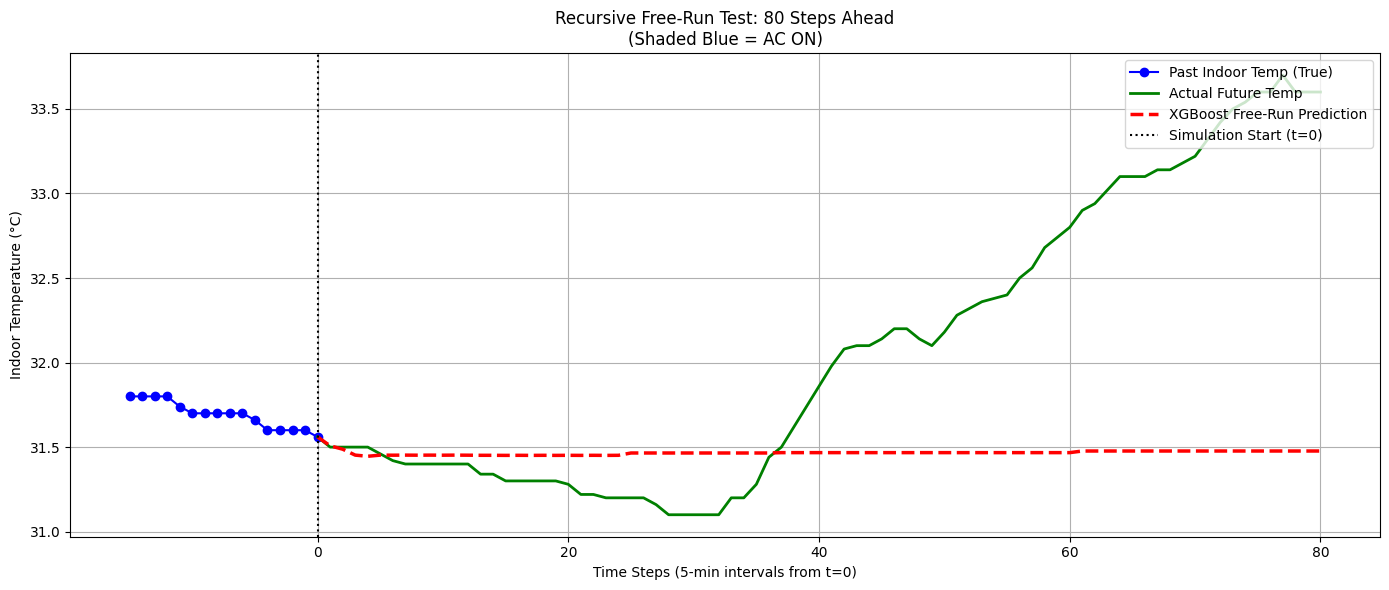

In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb

df = df_final.copy()


# ==========================================
# 1. PREPARE DATA WITH MOMENTUM & LAG FEATURES
# ==========================================
df['Hour_sin'] = np.sin(2 * np.pi * df['Datetime'].dt.hour / 24)
df['Hour_cos'] = np.cos(2 * np.pi * df['Datetime'].dt.hour / 24)

# Current thermodynamic differential
df['Temp_Diff'] = df['OutdoorTemp'] - df['IndoorTemp']

# --- NEW: Momentum and Lag Features ---
df['IndoorTemp_Lag1'] = df['IndoorTemp'].shift(1)
df['Temp_Change_Rate'] = df['IndoorTemp'] - df['IndoorTemp_Lag1']
df['AC_State_Lag1'] = df['AC_State'].shift(1)

# TARGET: Predicting exactly 1 step ahead
df['Target_Temp_Next_Step'] = df['IndoorTemp'].shift(-1)

# Drop rows with NaNs caused by shifting
df = df.dropna().reset_index(drop=True)

# Define exact feature order
features = [
    'IndoorTemp', 'OutdoorTemp', 'Temp_Diff', 'AC_State',
    'Hour_sin', 'Hour_cos', 'IndoorTemp_Lag1', 'Temp_Change_Rate', 'AC_State_Lag1'
]

X = df[features].values
y = df['Target_Temp_Next_Step'].values

# Chronological Train/Test Split (80/20)
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]
df_test = df.iloc[split:].reset_index(drop=True)


# ==========================================
# 2. TRAIN AUTOREGRESSIVE XGBOOST
# ==========================================
print("Training Autoregressive XGBoost...")
model = xgb.XGBRegressor(
    n_estimators=150,
    max_depth=4,
    learning_rate=0.05,
    objective='reg:squarederror'
)
model.fit(X_train, y_train)


# ==========================================
# 3. RECURSIVE FREE-RUN SIMULATION
# ==========================================
HORIZON = 80
past_context = 15  # We want to plot 15 steps of past data

# THE FIX: Ensure we start searching AFTER 'past_context' so slicing never goes negative
start_idx = past_context

for i in range(past_context, len(df_test) - HORIZON - 1):
    if df_test['AC_State'].iloc[i+1] == 1 and df_test['AC_State'].iloc[i] == 0:
        start_idx = i
        break

# Initialize simulation with real data at t=0
current_simulated_temp = df_test['IndoorTemp'].iloc[start_idx]
current_lag1_temp = df_test['IndoorTemp_Lag1'].iloc[start_idx]
current_ac_lag1 = df_test['AC_State_Lag1'].iloc[start_idx]

predictions = []
actuals = df_test['IndoorTemp'].iloc[start_idx + 1 : start_idx + 1 + HORIZON].values

print(f"Starting Free-Run Simulation for {HORIZON} steps...")

# The Recursive Loop
for step in range(HORIZON):
    current_idx = start_idx + step + 1

    # "Future Knowns" we are allowed to use
    outdoor_t = df_test['OutdoorTemp'].iloc[current_idx]
    ac = df_test['AC_State'].iloc[current_idx]
    hr_sin = df_test['Hour_sin'].iloc[current_idx]
    hr_cos = df_test['Hour_cos'].iloc[current_idx]

    # Calculate derived dynamic features using the SIMULATED temperature
    temp_diff = outdoor_t - current_simulated_temp
    temp_change_rate = current_simulated_temp - current_lag1_temp

    # Build feature vector matching the exact order of 'features' list
    X_step = np.array([[
        current_simulated_temp, outdoor_t, temp_diff, ac,
        hr_sin, hr_cos, current_lag1_temp, temp_change_rate, current_ac_lag1
    ]])

    # Predict step t+1
    next_temp = model.predict(X_step)[0]
    predictions.append(next_temp)

    # --- UPDATE VARIABLES FOR THE NEXT RECURSIVE LOOP ---
    current_lag1_temp = current_simulated_temp  # The current prediction becomes the lag for next round
    current_ac_lag1 = ac                        # Current AC becomes lag AC for next round
    current_simulated_temp = next_temp          # The prediction becomes the current temp for next round


# ==========================================
# 4. VISUALIZATION
# ==========================================
plt.figure(figsize=(14, 6))

# Context (Past data) - This slice is now guaranteed to be safe
past_actuals = df_test['IndoorTemp'].iloc[start_idx - past_context : start_idx + 1].values
time_past = range(-past_context, 1)
plt.plot(time_past, past_actuals, label='Past Indoor Temp (True)', color='blue', marker='o')

# Future Setup
time_future = range(1, HORIZON + 1)
time_pred = [0] + list(time_future) # Starts perfectly at X=0
actual_line = [past_actuals[-1]] + list(actuals)
pred_line = [past_actuals[-1]] + list(predictions)

plt.plot(time_pred, actual_line, label='Actual Future Temp', color='green', linewidth=2)
plt.plot(time_pred, pred_line, label='XGBoost Free-Run Prediction', color='red', linestyle='--', linewidth=2.5)

# Shade regions where AC is ON
for t, ac_is_on in zip(time_future, df_test['AC_State'].iloc[start_idx + 1 : start_idx + 1 + HORIZON]):
    if ac_is_on == 1:
        plt.axvspan(t-0.5, t+0.5, color='cyan', alpha=0.15, lw=0)

plt.axvline(x=0, color='black', linestyle=':', label='Simulation Start (t=0)')
plt.title(f"Recursive Free-Run Test: {HORIZON} Steps Ahead\n(Shaded Blue = AC ON)")
plt.xlabel("Time Steps (5-min intervals from t=0)")
plt.ylabel("Indoor Temperature (°C)")
plt.legend(loc='upper right')
plt.grid(True)
plt.tight_layout()
plt.show()

Training Autoregressive XGBoost on Delta-T...
Starting Delta-T Free-Run Simulation for 80 steps...


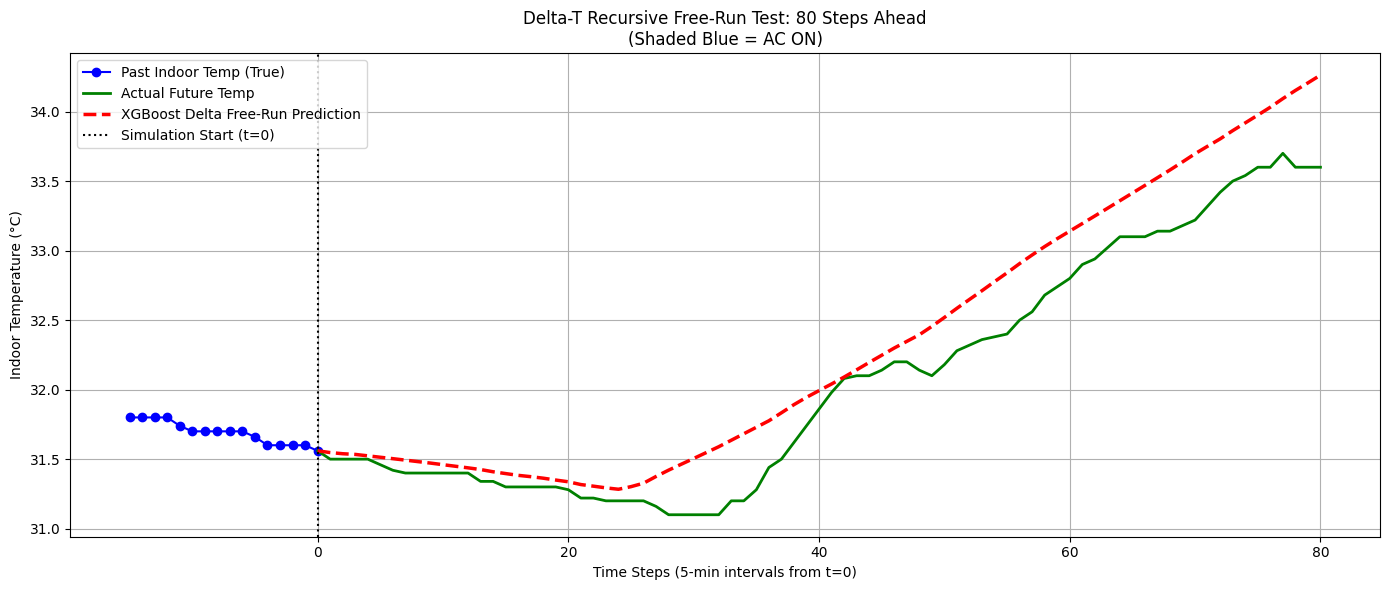

In [93]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb

# ==========================================
# 0. LOAD DATA
# ==========================================
# Use your actual real dataset
df = df_final.copy()

# Ensure Datetime is proper format and sorted chronologically
df['Datetime'] = pd.to_datetime(df['Datetime'])
df = df.sort_values('Datetime').reset_index(drop=True)

# ==========================================
# 1. PREPARE DATA FOR DELTA PREDICTION
# ==========================================
# Cyclical Time Features
df['Hour_sin'] = np.sin(2 * np.pi * df['Datetime'].dt.hour / 24)
df['Hour_cos'] = np.cos(2 * np.pi * df['Datetime'].dt.hour / 24)

# Thermodynamic drivers
df['Temp_Diff'] = df['OutdoorTemp'] - df['IndoorTemp']

# Lags & Momentum
df['IndoorTemp_Lag1'] = df['IndoorTemp'].shift(1)
df['Temp_Change_Rate'] = df['IndoorTemp'] - df['IndoorTemp_Lag1']
df['AC_State_Lag1'] = df['AC_State'].shift(1)

# THE CRITICAL FIX: The target is now the CHANGE in temperature (Delta-T)
df['Target_Delta_Next_Step'] = df['IndoorTemp'].shift(-1) - df['IndoorTemp']

# Drop NaNs caused by the shifting operations
df = df.dropna().reset_index(drop=True)

# Include ALL your real environmental features
features = [
    'IndoorTemp', 'IndoorHumidity', 'OutdoorTemp', 'OutdoorHumidity',
    'Rain', 'CloudCover', 'WindSpeed', 'Temp_Diff', 'AC_State',
    'Hour_sin', 'Hour_cos', 'IndoorTemp_Lag1', 'Temp_Change_Rate', 'AC_State_Lag1'
]

X = df[features].values
y = df['Target_Delta_Next_Step'].values # Training on Delta-T!

# Chronological Train/Test Split (80/20)
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]
df_test = df.iloc[split:].reset_index(drop=True)


# ==========================================
# 2. TRAIN AUTOREGRESSIVE XGBOOST
# ==========================================
print("Training Autoregressive XGBoost on Delta-T...")
model = xgb.XGBRegressor(
    n_estimators=300,        # Increased from 150 (gives it more time to learn)
    max_depth=6,             # Increased from 4 (allows it to learn more complex weather interactions)
    learning_rate=0.03,      # Lowered (slower learning + more estimators = more precise curves)
    subsample=0.8,           # Helps prevent overfitting while being aggressive
    colsample_bytree=0.8,
    objective='reg:squarederror'
)
model.fit(X_train, y_train)

# ==========================================
# 3. RECURSIVE FREE-RUN SIMULATION (DELTA MODE)
# ==========================================
HORIZON = 80       # Simulate 80 steps ahead (approx 6.5 hours)
past_context = 15  # Show 15 steps of history on the graph

# Pick a starting point. Let's find one where AC is currently OFF but turns ON soon,
# or just a general point if the AC doesn't turn on.
start_idx = past_context
for i in range(past_context, len(df_test) - HORIZON - 1):
    if df_test['AC_State'].iloc[i+1] == 1 and df_test['AC_State'].iloc[i] == 0:
        start_idx = i
        break

# Initialize simulation variables with real data at t=0
current_simulated_temp = df_test['IndoorTemp'].iloc[start_idx]
current_lag1_temp = df_test['IndoorTemp_Lag1'].iloc[start_idx]
current_ac_lag1 = df_test['AC_State_Lag1'].iloc[start_idx]

# We need a proxy for Future Indoor Humidity since we aren't predicting it.
# Standard practice is to hold the last known indoor humidity constant.
constant_indoor_h = df_test['IndoorHumidity'].iloc[start_idx]

predictions = []
actuals = df_test['IndoorTemp'].iloc[start_idx + 1 : start_idx + 1 + HORIZON].values

print(f"Starting Delta-T Free-Run Simulation for {HORIZON} steps...")

# The Recursive Loop
for step in range(HORIZON):
    current_idx = start_idx + step + 1

    # "Future Knowns" (Weather & AC Schedule)
    outdoor_t = df_test['OutdoorTemp'].iloc[current_idx]
    outdoor_h = df_test['OutdoorHumidity'].iloc[current_idx]
    rain = df_test['Rain'].iloc[current_idx]
    clouds = df_test['CloudCover'].iloc[current_idx]
    wind = df_test['WindSpeed'].iloc[current_idx]
    ac = df_test['AC_State'].iloc[current_idx]
    hr_sin = df_test['Hour_sin'].iloc[current_idx]
    hr_cos = df_test['Hour_cos'].iloc[current_idx]

    # Dynamic features calculated using the SIMULATED temperature, NOT the real one
    temp_diff = outdoor_t - current_simulated_temp
    temp_change_rate = current_simulated_temp - current_lag1_temp

    # Build feature vector (MUST perfectly match the exact order of the 'features' list above)
    X_step = np.array([[
        current_simulated_temp, constant_indoor_h, outdoor_t, outdoor_h,
        rain, clouds, wind, temp_diff, ac,
        hr_sin, hr_cos, current_lag1_temp, temp_change_rate, current_ac_lag1
    ]])

    # 1. Predict the DELTA (+0.05, -0.1, etc.)
    predicted_delta = model.predict(X_step)[0]

    # 2. The next temperature is Current + Delta
    next_temp = current_simulated_temp + predicted_delta
    predictions.append(next_temp)

    # 3. UPDATE VARIABLES FOR THE NEXT RECURSIVE LOOP
    current_lag1_temp = current_simulated_temp
    current_ac_lag1 = ac
    current_simulated_temp = next_temp


# ==========================================
# 4. VISUALIZATION
# ==========================================
plt.figure(figsize=(14, 6))

# Plot Past Context (True Data)
past_actuals = df_test['IndoorTemp'].iloc[start_idx - past_context : start_idx + 1].values
time_past = range(-past_context, 1)
plt.plot(time_past, past_actuals, label='Past Indoor Temp (True)', color='blue', marker='o')

# Future Setup
time_future = range(1, HORIZON + 1)
time_pred = [0] + list(time_future) # Anchored at X=0
actual_line = [past_actuals[-1]] + list(actuals)
pred_line = [past_actuals[-1]] + list(predictions)

# Plot Trajectories
plt.plot(time_pred, actual_line, label='Actual Future Temp', color='green', linewidth=2)
plt.plot(time_pred, pred_line, label='XGBoost Delta Free-Run Prediction', color='red', linestyle='--', linewidth=2.5)

# Shade regions where AC is ON
for t, ac_is_on in zip(time_future, df_test['AC_State'].iloc[start_idx + 1 : start_idx + 1 + HORIZON]):
    if ac_is_on == 1:
        plt.axvspan(t-0.5, t+0.5, color='cyan', alpha=0.15, lw=0)

plt.axvline(x=0, color='black', linestyle=':', label='Simulation Start (t=0)')
plt.title(f"Delta-T Recursive Free-Run Test: {HORIZON} Steps Ahead\n(Shaded Blue = AC ON)")
plt.xlabel("Time Steps (5-min intervals from t=0)")
plt.ylabel("Indoor Temperature (°C)")
plt.legend(loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()